# Practica N° 2 

* **Estudiante:** Moisés Abdel Andrés Torrez Huarina
* **Materia:** Machine Learning (INF672)
* **Universidad:** Universidad Autónoma Tomás Frías (UATF)
* **Carrera:** Ingeniería Informática


# Paso 1 : Preparar el entorno de trabajo

In [1]:
#Preparacion del Entorno
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error


| Librería / función | Para qué se usa |
|---|---|
| pandas | Cargar  el dataset insurance.csv como DataFrame y manipula sus columnas |
| matplotlib.pyplot | Herramienta para graficar los resultados obtenidos |
| train_test_split | Dividir los datos en entrenamiento y prueba |
| LinearRegression | Crear y entrenar el modelo de regresión lineal múltiple |
| r2_score | Medir la proporción de variación del costo que explica el modelo |
| mean_absolute_error | Medir el error promedio del modelo, en dólares |

## Paso 02: Cargar y conocer los datos

In [10]:
df= pd.read_csv("insurance.csv")
print("Dimensiones de la tabla", df.shape, "\n")
print("Primeras Filas \n",df.head(4), "\n")
print (df.info())

Dimensiones de la tabla (1338, 7) 

Primeras Filas 
    age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061 

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB
None



El dataset tiene 1.338 filas y 7 columnas. Cada fila representa a un asegurado individual, con sus características personales y el costo médico anual que terminó facturando. De las 7 columnas, tres contienen texto: sex, smoker y region; las otras cuatro contienen números: age, bmi, children y charges. La variable que se quiere predecir es charges, el costo médico anual en dólares.

# Paso 03 : Preparar los datos para el modelo

In [13]:
y = df['charges']
X = df.drop(columns='charges')
X = pd.get_dummies(X, drop_first=True, dtype=int)

print(list(X.columns))
X.head()

['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,0,1,0,0,1
1,18,33.770,1,1,0,0,1,0
2,28,33.000,3,1,0,0,1,0
3,33,22.705,0,1,0,1,0,0
4,32,28.880,0,1,0,1,0,0



Las 6 variables originales se convirtieron en 8 columnas: age, bmi y children quedaron igual porque ya eran numéricas, mientras que sex, smoker y region se transformaron en columnas binarias (0 o 1) mediante one-hot encoding. sex generó una sola columna (sex_male), smoker generó una sola columna (smoker_yes), y region generó tres columnas (region_northwest, region_southeast, region_southwest).

El parámetro drop_first=True elimina la primera categoría de cada variable para evitar crear una columna redundante. No se pierde información al hacerlo porque esa categoría de referencia queda representada implícitamente cuando todas las demás columnas de esa variable valen 0: por ejemplo, una fila con region_northwest=0, region_southeast=0 y region_southwest=0 corresponde, por descarte, a northeast. Si se hubiera incluido una columna por cada categoría, el modelo no podría distinguir los coeficientes de forma única, porque una de las columnas sería combinación lineal de las otras (problema conocido como colinealidad perfecta o trampa de las variables ficticias).

# Paso 04 :Dividir en entrenamiento y prueba

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print('Entrenamiento:', X_train.shape[0], 'filas')
print('Prueba:', X_test.shape[0], 'filas')

Entrenamiento: 1070 filas
Prueba: 268 filas
1338


Quedaron 1.070 filas en el conjunto de entrenamiento y 268 en el de prueba. No se debe evaluar el modelo con los mismos datos con los que se entrenó porque el modelo ya vio esos casos durante el aprendizaje y podría simplemente haber memorizado sus particularidades en lugar de haber aprendido un patrón general; eso haría que el desempeño medido pareciera mejor de lo que realmente sería frente a asegurados nuevos. El parámetro random_state fija la semilla que controla cómo se reparten aleatoriamente las filas entre ambos conjuntos, de modo que la división sea exactamente la misma cada vez que se ejecute el código. Si no se fijara, cada ejecución generaría una división distinta y, en consecuencia, resultados de entrenamiento y métricas ligeramente diferentes cada vez, lo que dificultaría comparar resultados o reproducir el experimento.

# Paso 05 :Entrenar el modelo

In [17]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 256.98, 337.09, 425.28,...,-370.68,-657.86,-809.8 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['age','bmi','children',...,'region_northwest','region_southeast', 'region_southwest']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.193e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


El método fit calcula el intercepto y los coeficientes que minimizan la suma de los errores al cuadrado entre las predicciones del modelo y los costos reales del conjunto de entrenamiento (el criterio de mínimos cuadrados ordinarios). La regresión lineal no prueba combinaciones al azar: resuelve el problema de forma directa mediante álgebra lineal, encontrando el único conjunto de coeficientes que produce el menor error cuadrático posible sobre esos datos.

La ecuación general del modelo, con las columnas de X, queda:

charges = b + w1·age + w2·bmi + w3·children + w4·sex_male + w5·smoker_yes + w6·region_northwest + w7·region_southeast + w8·region_southwest

# Paso 06 :Evaluar el modelo

In [18]:
y_pred = modelo.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mediana = df['charges'].median()

print(f'R²  = {r2:.4f}')
print(f'MAE = {mae:.2f} USD')
print(f'Mediana de charges = {mediana:.2f} USD')

R²  = 0.7836
MAE = 4181.19 USD
Mediana de charges = 9382.03 USD


El modelo obtuvo un R² de 0.7836 y un MAE de 4.181,19 USD. El R² indica que el modelo explica aproximadamente el 78% de la variación del costo médico anual entre los asegurados del conjunto de prueba; el 22% restante queda sin explicar por estas seis variables, probablemente por factores no incluidos en el dataset (condiciones de salud preexistentes, hábitos, genética, etc.). El MAE indica que, en promedio, la predicción del modelo se equivoca en unos 4.181 USD respecto al costo real.

Comparando el MAE con la mediana del costo (9.382,03 USD), el error representa cerca del 45% de un seguro típico, lo cual es un margen considerable para una compañía que fija precios individuales: un error de esa magnitud puede significar pérdidas importantes en asegurados subestimados o precios poco competitivos en los sobrestimados. El modelo puede considerarse un punto de partida razonable, útil para tener una primera estimación y para entender qué variables influyen en el costo, pero probablemente no sea lo bastante preciso para fijar primas individuales sin ajustes adicionales o variables adicionales.

# Paso 07 :Interpretar los coeficientes

In [19]:
print('Intercepto:', modelo.intercept_)

coeficientes = pd.Series(modelo.coef_, index=X.columns).sort_values()
coeficientes

Intercepto: -11931.219050326674


region_southwest     -809.799354
region_southeast     -657.864297
region_northwest     -370.677326
sex_male              -18.591692
age                   256.975706
bmi                   337.092552
children              425.278784
smoker_yes          23651.128856
dtype: float64

El intercepto es -11.931,22 USD y los coeficientes, de menor a mayor, son: region_southwest -809,80; region_southeast -657,86; region_northwest -370,68; sex_male -18,59; age 256,98; bmi 337,09; children 425,28; smoker_yes 23.651,13.

La variable que más aumenta el costo, por amplio margen, es smoker_yes: fumar se asocia con un incremento de 23.651,13 USD respecto a no fumar, manteniendo las demás variables fijas. Como ejemplo de variable numérica, el coeficiente de bmi (337,09) indica que, por cada punto adicional de índice de masa corporal, el costo anual estimado aumenta en 337,09 USD. Como ejemplo de variable binaria, sex_male (-18,59) indica que, siendo hombre en vez de mujer (la categoría de referencia), el costo estimado disminuye en apenas 18,59 USD, una diferencia prácticamente insignificante frente al resto de las variables.

El intercepto no tiene una interpretación práctica directa en este caso: correspondería al costo estimado de una persona con age=0, bmi=0, sin hijos, mujer, no fumadora, de la región northeast — una combinación que no existe en la realidad (nadie tiene bmi o edad igual a cero). El intercepto funciona aquí como una constante matemática necesaria para ajustar la recta, no como un valor interpretable por sí solo.

Un coeficiente pequeño no significa necesariamente que su variable tenga poca influencia real, porque el efecto total depende también del rango de valores que toma esa variable. El coeficiente de age (256,98) es mucho menor que el de smoker_yes, pero age varía en un rango amplio (de 18 a 64 años aproximadamente), así que su efecto acumulado a lo largo de ese rango puede ser considerable (más de 10.000 USD de diferencia entre el asegurado más joven y el más longevo). En cambio, una variable binaria como sex_male solo puede tomar los valores 0 o 1, así que su coeficiente ya representa el efecto máximo posible de esa variable, por chico que sea.

# Paso 08 :Visualizar las predicciones

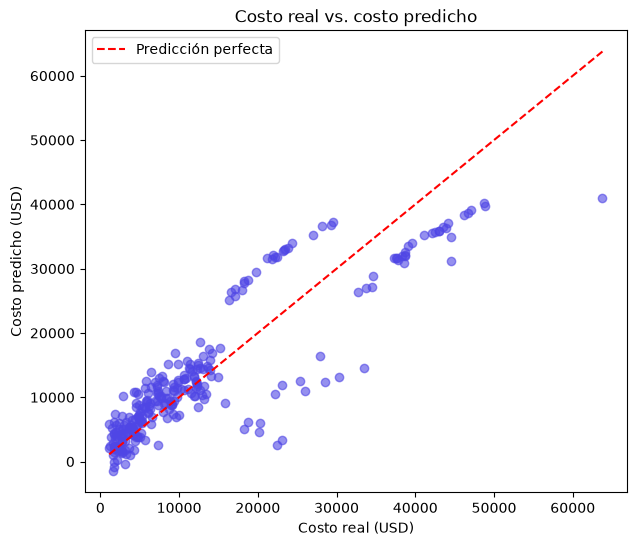

In [20]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='#4F46E5')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', label='Predicción perfecta')
plt.xlabel('Costo real (USD)')
plt.ylabel('Costo predicho (USD)')
plt.title('Costo real vs. costo predicho')
plt.legend()
plt.show()

El modelo predice mejor en el rango de costos bajos y medios (aproximadamente hasta 15.000-20.000 USD), donde los puntos se agrupan relativamente cerca de la diagonal de predicción perfecta. En el rango de costos altos, el modelo predice notablemente peor: aparecen varios puntos bastante alejados de la diagonal, y en general por debajo de ella, lo que indica que el modelo subestima el costo real de los asegurados más caros.

Se observan además dos o tres agrupaciones de puntos separadas entre sí en lugar de una nube continua, lo cual sugiere que existe alguna variable categórica no capturada completamente por el modelo lineal que separa a los asegurados en grupos con comportamientos de costo distintos. La hipótesis más probable es que esos grupos corresponden a la combinación de fumar y el índice de masa corporal: un fumador con bmi alto probablemente tenga un costo desproporcionadamente mayor que la suma de los efectos individuales de smoker_yes y bmi por separado, una interacción que una regresión lineal simple (sin términos de interacción) no puede capturar, y que explicaría por qué justamente los asegurados más caros son los peor predichos.

# Paso 09 :Predecir el costo de nuevos solicitantes

In [21]:
nuevos = pd.DataFrame([
    {'age': 45, 'sex': 'male',   'bmi': 33.5, 'children': 2, 'smoker': 'yes', 'region': 'southeast'},
    {'age': 45, 'sex': 'male',   'bmi': 33.5, 'children': 2, 'smoker': 'no',  'region': 'southeast'},
    {'age': 25, 'sex': 'female', 'bmi': 22.0, 'children': 0, 'smoker': 'no',  'region': 'northwest'},
])

nuevos_codificados = pd.get_dummies(nuevos, drop_first=True, dtype=int)
nuevos_codificados = nuevos_codificados.reindex(columns=X.columns, fill_value=0)

predicciones = modelo.predict(nuevos_codificados)
for nombre, pred in zip(['A', 'B', 'C'], predicciones):
    print(f'Solicitante {nombre}: {pred:.2f} USD')

Solicitante A: 34750.52 USD
Solicitante B: 11099.39 USD
Solicitante C: 1909.21 USD



Las predicciones fueron: Solicitante A (fumador) 34.750,52 USD; Solicitante B (no fumador, idéntico a A en todo lo demás) 11.099,39 USD; Solicitante C 1.909,21 USD.

El paso de reindex es necesario porque pd.get_dummies solo genera columnas para las categorías que efectivamente aparecen en los datos nuevos. Como estos tres solicitantes no cubren todas las regiones del dataset original (por ejemplo, ninguno pertenece a southwest), el get_dummies de los nuevos datos generaría menos columnas que las que tiene X, y en un orden que no necesariamente coincide. Sin el reindex, al intentar usar modelo.predict con una tabla que tiene distinta cantidad o distinto orden de columnas que las usadas en el entrenamiento, el modelo aplicaría cada coeficiente a la columna equivocada o directamente arrojaría un error, porque internamente la multiplicación de coeficientes por valores se hace por posición, no por nombre de columna.

Los solicitantes A y B solo difieren en si fuman o no, y la diferencia entre sus predicciones es de 23.651,13 USD (A menos B), exactamente igual al coeficiente de smoker_yes obtenido en el Paso 07. Esto confirma de forma concreta cómo se interpreta un coeficiente de regresión lineal: al mantener todas las demás variables idénticas y cambiar solo smoker de "no" a "yes", la predicción del modelo aumenta exactamente en el valor de ese coeficiente.